# Dynamics-Aware Gradient Clipping — Small-Scale Experiment

**Project:** Paper 02 (AI application) — *Dynamics-aware gradient clipping for neural network training: stability, switching dynamics, and trajectory control.*

This notebook runs a small-scale comparison of **no clipping vs fixed global-norm clipping vs DAGC** (Dynamics-Aware Adaptive Gradient Clipping) on FashionMNIST with a small CNN, and visualizes the training dynamics:

- train loss
- gradient norm
- gradient alignment \(C_1(t)\)
- clipping threshold \(c_t\)
- clipping exposure / switching events
- Hessian top eigenvalue (stability pressure \(S_t = \eta \lambda_{\max}\))

Research outlines: [English](../ai_paper_research_outline/ai_paper_research_outline.pdf) · [Chinese](../人工智能论文研究大纲/ai_research_outline_cn.pdf)


In [1]:
# 1. Setup
import sys, time
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from src.train import train_run

print("root:", ROOT)

root: E:\Paper\Paper_02_Application in AI\Experiments for AI


## 2. Experiment configuration

Small CNN (2 conv + 2 fc) on FashionMNIST, SGD with momentum. Change `EPOCHS` for longer runs.


In [2]:
EPOCHS   = 5      # training epochs per policy
SEED     = 0
NUM_WORKERS = 0   # 0 avoids DataLoader spawn issues inside notebooks
DEVICE   = "cuda"

def base_cfg(seed=SEED, epochs=EPOCHS):
    return {
        "model": "small_cnn",
        "dataset": "fashion_mnist",
        "data_dir": str(ROOT / "data"),
        "epochs": epochs,
        "batch_size": 256,
        "lr": 0.1,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "optimizer": "sgd",
        "seed": seed,
        "device": DEVICE,
        "num_workers": NUM_WORKERS,
        "projection_dim": 4,
        "hessian_epochs": [max(0, epochs - 1)],  # one Hessian checkpoint at the end
    }

## 3. Probe: estimate the gradient-norm scale

A short no-clipping run estimates the median gradient norm; the fixed-clipping threshold is set to that median (transition regime). DAGC starts from the same scale.


In [3]:
print("[probe] 2 epochs without clipping ...")
probe_cfg = base_cfg(epochs=min(2, EPOCHS))
probe_cfg["clipping"] = {"name": "none"}
probe = train_run(probe_cfg)
med_gn = probe["median_grad_norm"]
print(f"median ||g|| = {med_gn:.4f}  ->  fixed threshold c = {med_gn:.4f}")

[probe] 2 epochs without clipping ...


median ||g|| = 0.6675  ->  fixed threshold c = 0.6675


## 4. Train the three policies

In [4]:
policies = [
    ("none",  {"name": "none"}),
    ("fixed", {"name": "fixed", "threshold": float(med_gn)}),
    ("dagc",  {"name": "dagc", "gamma": 0.05, "beta": 0.9, "init_c": float(med_gn)}),
]

results = {}
for name, clip in policies:
    print(f"[run] policy = {name} ({EPOCHS} epochs) ...")
    t0 = time.time()
    cfg = base_cfg()
    cfg["clipping"] = clip
    results[name] = train_run(cfg)
    r = results[name]
    print(f"      done in {time.time()-t0:.1f}s | test acc = {r['test_acc']*100:.2f}%")

[run] policy = none (5 epochs) ...


      done in 53.6s | test acc = 89.51%
[run] policy = fixed (5 epochs) ...


      done in 54.4s | test acc = 90.20%
[run] policy = dagc (5 epochs) ...


      done in 55.1s | test acc = 89.75%


## 5. Summary table

\[\text{mean}C_1 = \text{mean}\; \langle g_t, g_{t+1}\rangle / (\|g_t\|\|g_{t+1}\|)\]
\[\text{loss\_freq} = \text{dominant frequency of the loss series}\]

Negative mean \(C_1\) and nonzero loss frequency indicate oscillatory / alternating dynamics.


In [5]:
print(f"{'policy':<8} {'test_acc':>9} {'mean_loss':>9} {'F_clip':>7} {'I_clip':>7} {'N_switch':>9} {'meanC1':>8} {'meanC2':>8} {'loss_freq':>9}")
for name in ["none", "fixed", "dagc"]:
    r = results[name]
    print(f"{name:<8} {r['test_acc']*100:>8.2f}% {r['mean_loss']:>9.4f} {r['f_clip']:>7.3f} "
          f"{r['i_clip']:>7.3f} {r['n_switch']:>9d} {r['mean_c1']:>8.3f} {r['mean_c2']:>8.3f} {r['loss_dom_freq']:>9.4f}")

print()
print("Hessian top eigenvalues at checkpoints (stability pressure S_t = eta * lambda_max):")
for name in ["none", "fixed", "dagc"]:
    he = results[name].get("hessian_evals", [])
    print(f"  [{name}] " + ", ".join(f"epoch {e}: lambda_max={lam:.3f}, S={0.1*lam:.4f}" for e, lam in he))

policy    test_acc mean_loss  F_clip  I_clip  N_switch   meanC1   meanC2 loss_freq
none        89.51%    0.2008   0.000   0.000         0    0.214    0.030    0.0009
fixed       90.20%    0.1881   0.593   0.169       390    0.220   -0.053    0.0009
dagc        89.75%    0.1798   0.140   0.066        37    0.186   -0.039    0.0009

Hessian top eigenvalues at checkpoints (stability pressure S_t = eta * lambda_max):
  [none] epoch 4: lambda_max=0.000, S=0.0000
  [fixed] epoch 4: lambda_max=0.000, S=0.0000
  [dagc] epoch 4: lambda_max=0.000, S=0.0000


## 6. Visualization

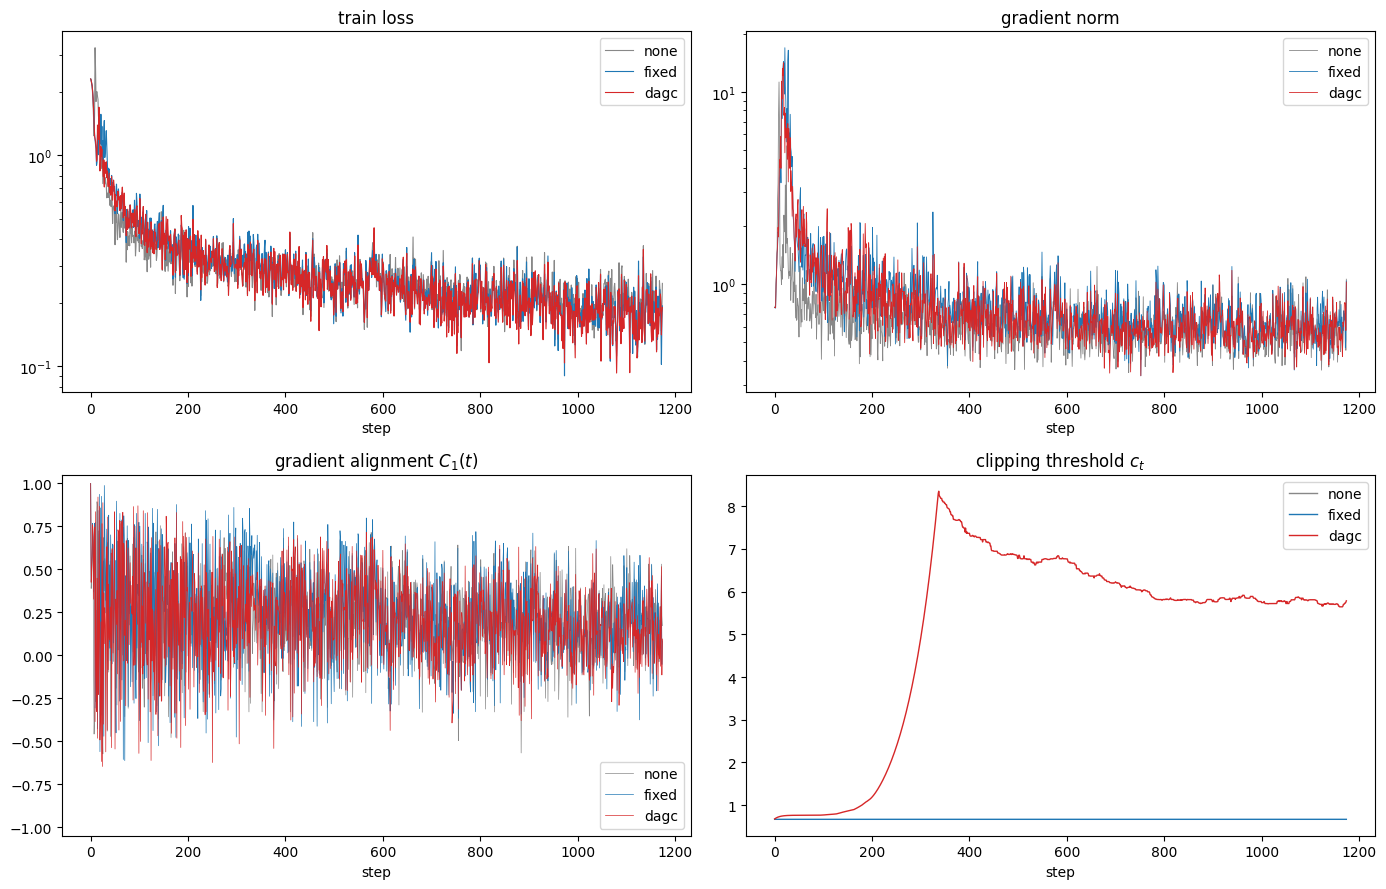

In [6]:
colors = {"none": "#888888", "fixed": "#1f77b4", "dagc": "#d62728"}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for name in ["none", "fixed", "dagc"]:
    lg = results[name]["log"]
    t = np.arange(len(lg["loss"]))
    axes[0, 0].plot(t, lg["loss"], label=name, color=colors[name], lw=0.8)
    axes[0, 1].plot(t, lg["grad_norm"], label=name, color=colors[name], lw=0.6)
    axes[1, 0].plot(t, lg["alignment"], label=name, color=colors[name], lw=0.5)
    axes[1, 1].plot(t, lg["threshold"], label=name, color=colors[name], lw=1.0)
axes[0, 0].set_title("train loss"); axes[0, 0].set_yscale("log"); axes[0, 0].legend()
axes[0, 1].set_title("gradient norm"); axes[0, 1].set_yscale("log"); axes[0, 1].legend()
axes[1, 0].set_title("gradient alignment $C_1(t)$"); axes[1, 0].set_ylim(-1.05, 1.05); axes[1, 0].legend()
axes[1, 1].set_title("clipping threshold $c_t$"); axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()

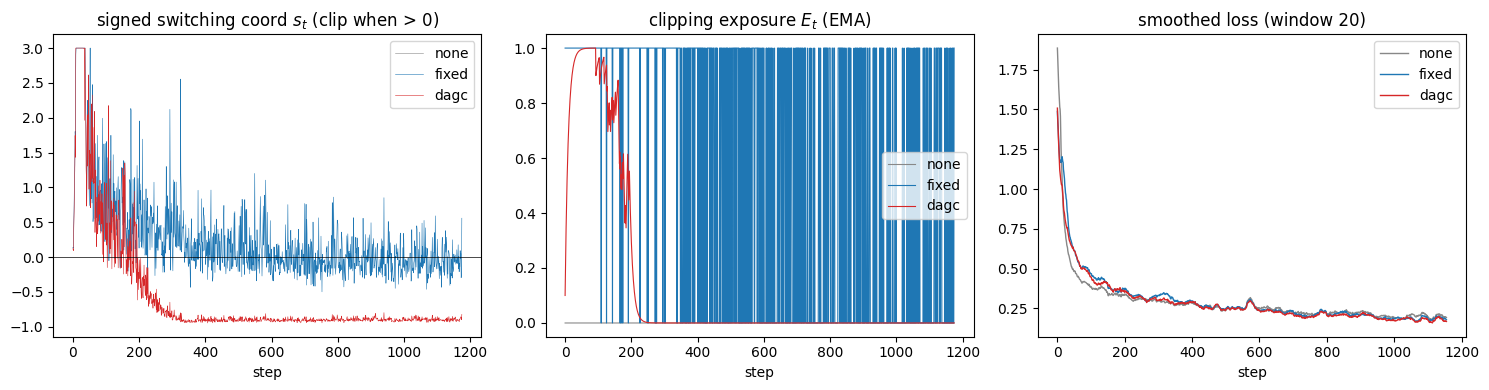

In [7]:
# Exposure, switching and oscillation detail (per policy)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in ["none", "fixed", "dagc"]:
    lg = results[name]["log"]
    t = np.arange(len(lg["loss"]))
    s = np.clip(np.array(lg["grad_norm"]) / (np.array(lg["threshold"]) + 1e-12) - 1, -1, 3)
    axes[0].plot(t, s, label=name, color=colors[name], lw=0.4)
    axes[1].plot(t, lg["exposure"], label=name, color=colors[name], lw=0.8)
    sm = np.convolve(lg["loss"], np.ones(20)/20, mode="valid")
    axes[2].plot(sm, label=name, color=colors[name], lw=1.0)
axes[0].axhline(0, color="k", lw=0.5); axes[0].set_title("signed switching coord $s_t$ (clip when > 0)")
axes[1].set_title("clipping exposure $E_t$ (EMA)")
axes[2].set_title("smoothed loss (window 20)")
for ax in axes: ax.set_xlabel("step"); ax.legend()
plt.tight_layout(); plt.show()

## 7. How to read this

- **none** (grey): baseline SGD. Watch the loss curve and the alignment \(C_1\) for oscillations.
- **fixed** (blue): clipping at the probe median. Compare exposure, switching count and test accuracy.
- **dagc** (red): the adaptive controller. Check that the threshold \(c_t\) relaxes in stable phases and tightens when the alignment / exposure signal degrades, and whether it preserves or improves stability without hurting accuracy.

If the loss frequency is near 0 and \(C_1\) is near +1, training is smooth; strong negative \(C_1\) with a nonzero dominant frequency is the signature of alternating (period-2-like) dynamics that clipping can reshape.

> **Note:** this is a diagnostic-scale run. Formal claims require the A1-A9 protocol (>=5 seeds, matched-update controls, etc.) in `docs/experiments_A0_A9.md`.